In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import catboost as cb
import os
import pickle
import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Положи файлы в Drive в папку hackathon
DATA_PATH = '/content/drive/MyDrive/WB/'

# Проверка
!ls {DATA_PATH}

# Загрузка
train = pd.read_parquet(DATA_PATH + 'train_team_track.parquet')
test = pd.read_parquet(DATA_PATH + 'test_team_track.parquet')

print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
train

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,4,29,2025-03-01 00:00:00,3105,340,2160,484,4018,3462,0,0,27.0
1,4,29,2025-03-01 00:30:00,2813,388,2058,373,1363,1657,9380,0,27.0
2,4,29,2025-03-01 01:00:00,2465,293,2098,472,3195,3325,0,0,23.0
3,4,29,2025-03-01 01:30:00,1977,252,2351,310,3314,3243,0,0,37.0
4,4,29,2025-03-01 02:00:00,1585,206,2500,300,2130,1604,0,0,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4341995,53,526,2025-05-30 08:30:00,0,72,0,418,404,221,0,548,99.0
4341996,53,526,2025-05-30 09:00:00,0,60,0,275,551,686,783,525,91.0
4341997,53,526,2025-05-30 09:30:00,0,96,0,258,695,564,0,1150,89.0
4341998,53,526,2025-05-30 10:00:00,0,85,0,274,896,1547,0,1430,88.0


In [ ]:
print(train.columns.tolist())

['office_from_id', 'route_id', 'timestamp', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8', 'target_2h']


In [ ]:
print(train.dtypes)

office_from_id             int64
route_id                   int64
timestamp         datetime64[ns]
status_1                   int64
status_2                   int64
status_3                   int64
status_4                   int64
status_5                   int64
status_6                   int64
status_7                   int64
status_8                   int64
target_2h                float64
dtype: object


In [ ]:
missing = train.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет!")

Пропусков нет!


In [ ]:
print(f"\n🔄 Дубликаты строк: {train.duplicated().sum()}")


🔄 Дубликаты строк: 0



Статистика:
Среднее: 68.75
Медиана: 48.00
Минимум: 0.00
Максимум: 1517.00
Стандартное отклонение: 67.49

Доля нулевых значений: 211301 (4.87%)


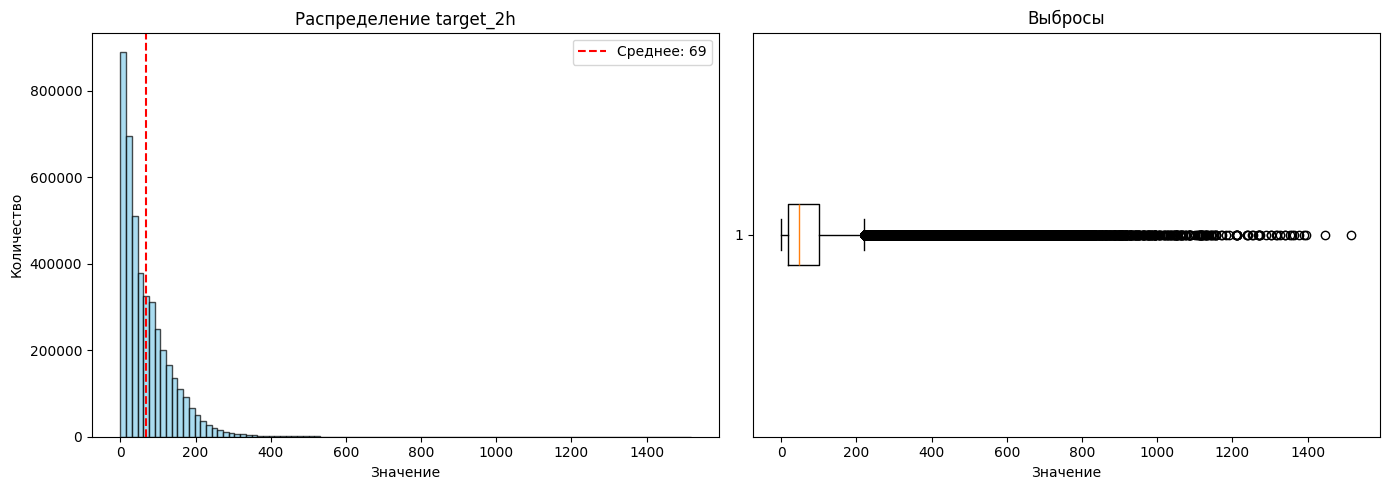

In [ ]:
target = train['target_2h']

print(f"\nСтатистика:")
print(f"Среднее: {target.mean():.2f}")
print(f"Медиана: {target.median():.2f}")
print(f"Минимум: {target.min():.2f}")
print(f"Максимум: {target.max():.2f}")
print(f"Стандартное отклонение: {target.std():.2f}")

# Доля нулей
zeros = (target == 0).sum()
print(f"\nДоля нулевых значений: {zeros} ({zeros / len(target) * 100:.2f}%)")

# График распределения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(target, bins=100, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_title('Распределение target_2h')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Количество')
axes[0].axvline(target.mean(), color='red', linestyle='--', label=f'Среднее: {target.mean():.0f}')
axes[0].legend()

axes[1].boxplot(target.values, vert=False)
axes[1].set_title('Выбросы')
axes[1].set_xlabel('Значение')

plt.tight_layout()
plt.show()


Среднее значение по статусам:
status_1: 1310.75
status_2: 147.00
status_3: 1278.57
status_4: 1103.00
status_5: 1555.77
status_6: 1555.74
status_7: 2243.07
status_8: 916.17


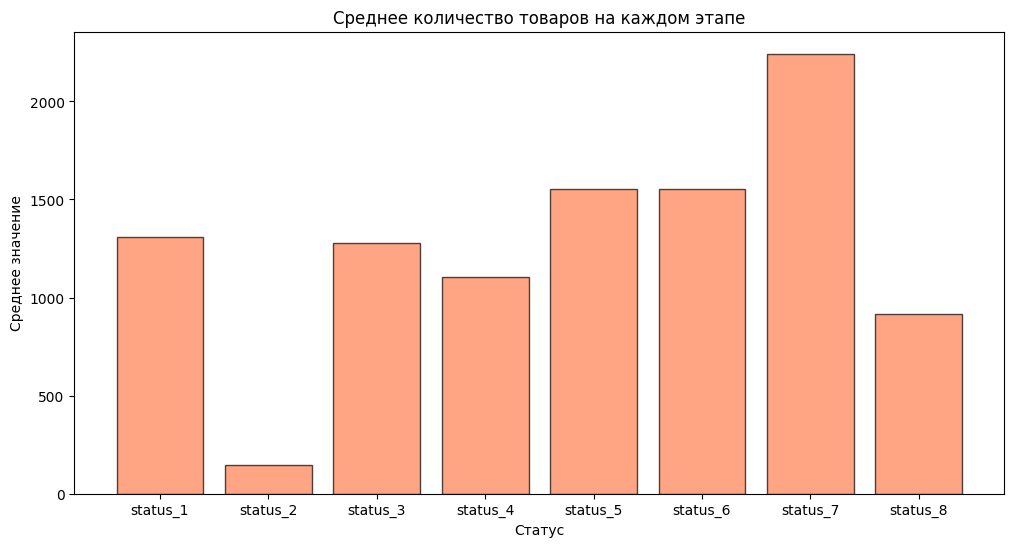

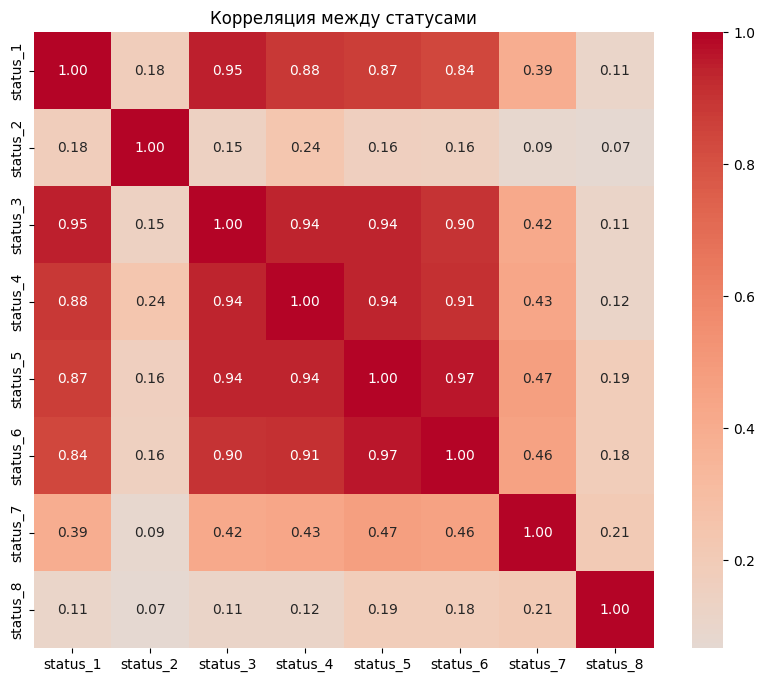

In [ ]:
status_cols = [f'status_{i}' for i in range(1, 9)]

print(f"\nСреднее значение по статусам:")
for col in status_cols:
    print(f"{col}: {train[col].mean():.2f}")

# График средних значений
plt.figure(figsize=(12, 6))
means = [train[col].mean() for col in status_cols]
plt.bar(status_cols, means, edgecolor='black', alpha=0.7, color='coral')
plt.title('Среднее количество товаров на каждом этапе')
plt.xlabel('Статус')
plt.ylabel('Среднее значение')
plt.show()

# Корреляция между статусами
plt.figure(figsize=(10, 8))
correlation = train[status_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляция между статусами')
plt.show()

status_1: 0.390
status_2: 0.086
status_3: 0.423
status_4: 0.426
status_5: 0.481
status_6: 0.468
status_7: 0.333
status_8: 0.335


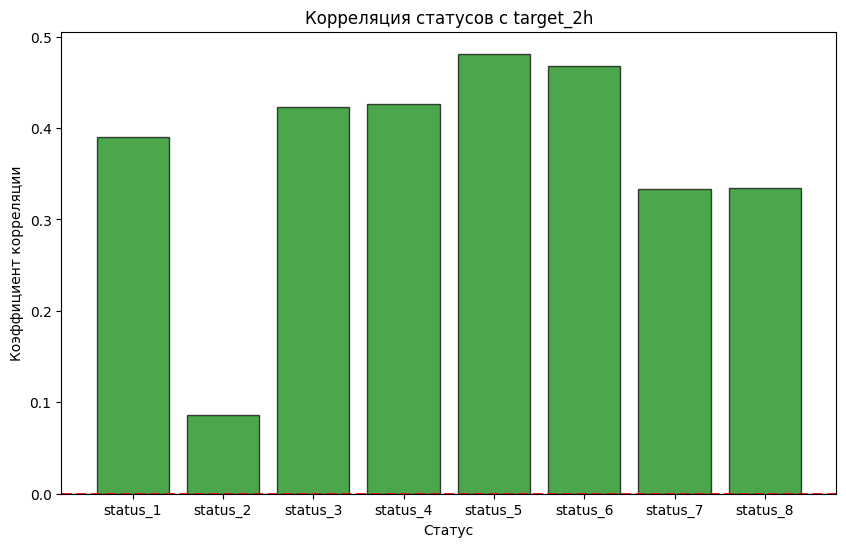


Самый важный статус: status_5 (корреляция 0.481)


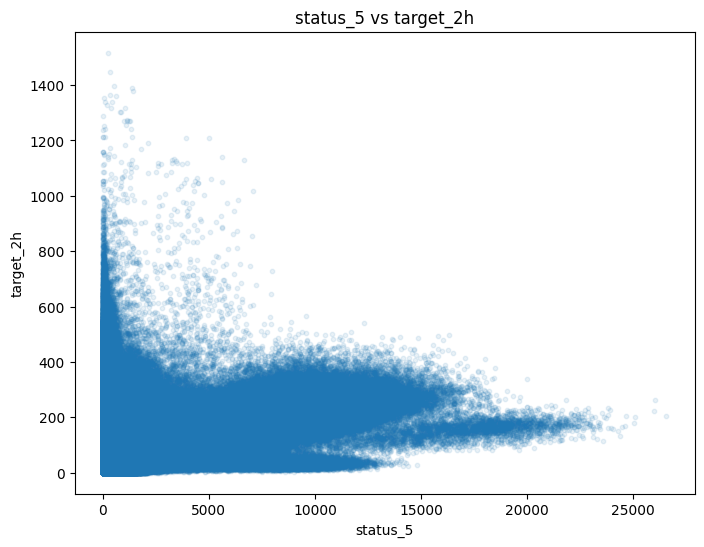

In [ ]:
correlations = []
for col in status_cols:
    corr = train[col].corr(train['target_2h'])
    correlations.append(corr)
    print(f"{col}: {corr:.3f}")

plt.figure(figsize=(10, 6))
plt.bar(status_cols, correlations, edgecolor='black', alpha=0.7, color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Корреляция статусов с target_2h')
plt.xlabel('Статус')
plt.ylabel('Коэффициент корреляции')
plt.show()

best_idx = np.argmax(correlations)
best_status = status_cols[best_idx]
print(f"\nСамый важный статус: {best_status} (корреляция {correlations[best_idx]:.3f})")

plt.figure(figsize=(8, 6))
plt.scatter(train[best_status], train['target_2h'], alpha=0.1, s=10)
plt.title(f'{best_status} vs target_2h')
plt.xlabel(best_status)
plt.ylabel('target_2h')
plt.show()


Средний target_2h по часам суток:
hour
0     70.617099
1     70.310984
2     69.206385
3     68.326989
4     67.014324
5     65.559044
6     64.269560
7     63.381643
8     63.767797
9     60.984918
10    56.907418
11    60.235467
12    65.964522
13    68.710367
14    70.753294
15    73.162978
16    74.992428
17    75.965011
18    76.930339
19    77.021594
20    76.738017
21    73.310322
22    68.002917
23    68.149239
Name: target_2h, dtype: float64


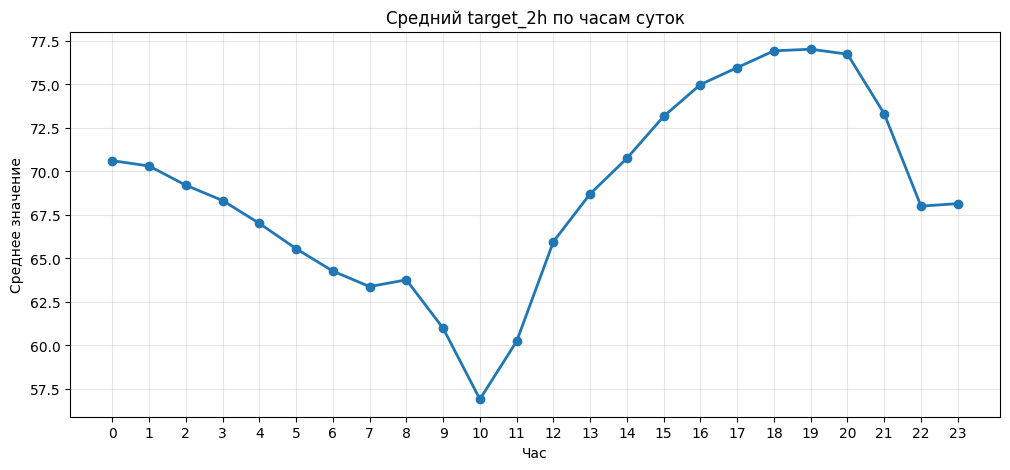

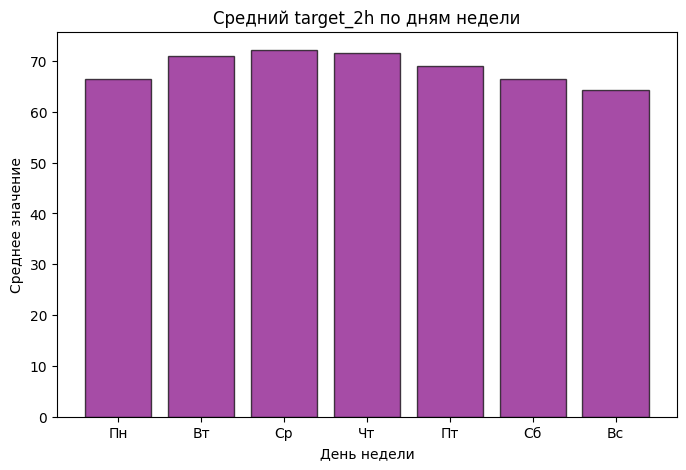

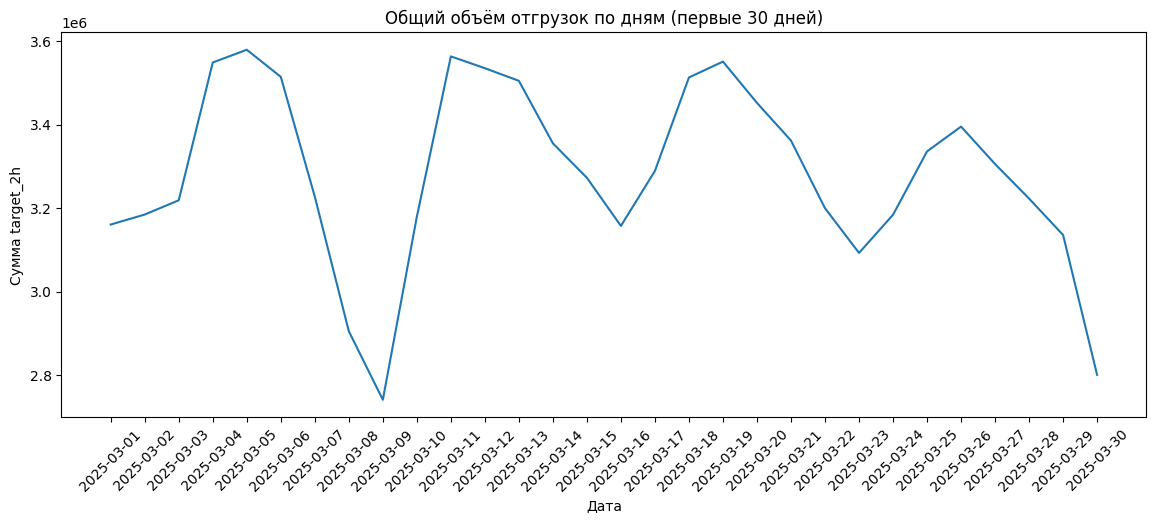

In [ ]:
train['timestamp'] = pd.to_datetime(train['timestamp'])

train['hour'] = train['timestamp'].dt.hour
train['day_of_week'] = train['timestamp'].dt.dayofweek
train['date'] = train['timestamp'].dt.date

print(f"\nСредний target_2h по часам суток:")
hourly = train.groupby('hour')['target_2h'].mean()
print(hourly)

# График по часам
plt.figure(figsize=(12, 5))
plt.plot(hourly.index, hourly.values, marker='o', linewidth=2)
plt.title('Средний target_2h по часам суток')
plt.xlabel('Час')
plt.ylabel('Среднее значение')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.show()

# График по дням недели
plt.figure(figsize=(8, 5))
dow = train.groupby('day_of_week')['target_2h'].mean()
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
plt.bar(days, dow.values, edgecolor='black', alpha=0.7, color='purple')
plt.title('Средний target_2h по дням недели')
plt.xlabel('День недели')
plt.ylabel('Среднее значение')
plt.show()

# Динамика по датам (первые 30 дней)
plt.figure(figsize=(14, 5))
daily = train.groupby('date')['target_2h'].sum().head(30)
plt.plot(daily.index.astype(str), daily.values)
plt.title('Общий объём отгрузок по дням (первые 30 дней)')
plt.xlabel('Дата')
plt.ylabel('Сумма target_2h')
plt.xticks(rotation=45)
plt.show()


Уникальных маршрутов (route_id): 1000
Уникальных складов (office_from_id): 53

Топ-10 маршрутов по объёму отгрузок:
route_id
79     1252582.0
960    1234746.0
956    1152752.0
537    1102908.0
340    1073483.0
827    1049131.0
706    1030450.0
268    1018897.0
641    1016686.0
409    1007449.0
Name: target_2h, dtype: float64

Топ-5 складов по объёму:
office_from_id
12    38449786.0
1     27236672.0
22    23652198.0
10    19022011.0
21    17792389.0
Name: target_2h, dtype: float64


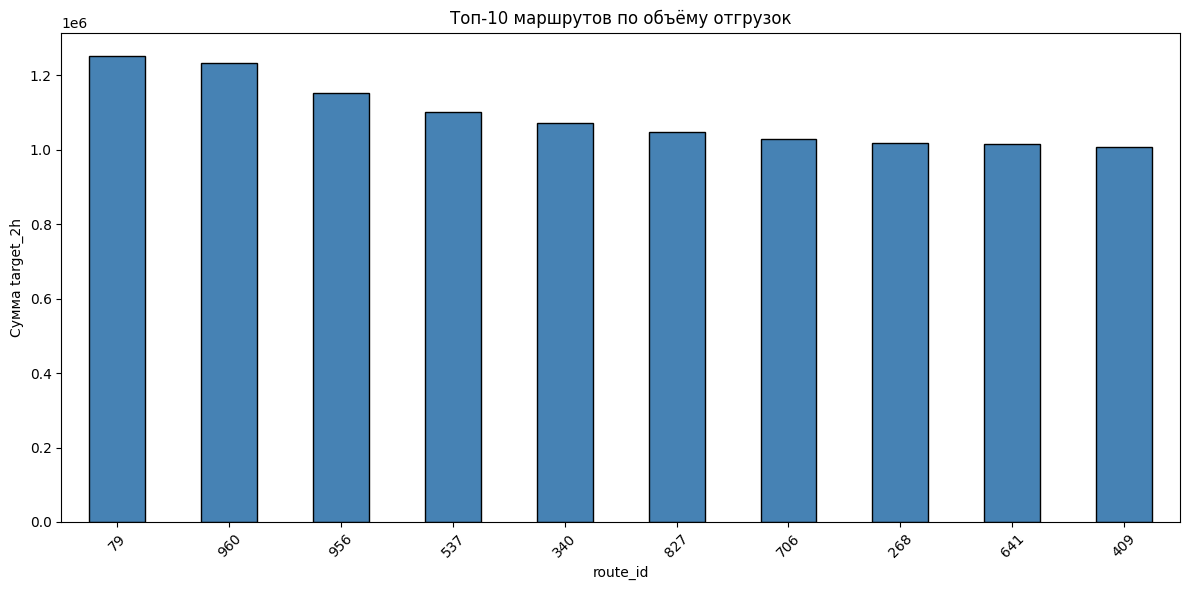

In [ ]:
print(f"\nУникальных маршрутов (route_id): {train['route_id'].nunique()}")
print(f"Уникальных складов (office_from_id): {train['office_from_id'].nunique()}")

# Топ-10 маршрутов по объёму
print(f"\nТоп-10 маршрутов по объёму отгрузок:")
top_routes = train.groupby('route_id')['target_2h'].sum().sort_values(ascending=False).head(10)
print(top_routes)

# Топ-5 складов
print(f"\nТоп-5 складов по объёму:")
top_offices = train.groupby('office_from_id')['target_2h'].sum().sort_values(ascending=False).head(5)
print(top_offices)

# График топ-10 маршрутов
plt.figure(figsize=(12, 6))
top_routes.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Топ-10 маршрутов по объёму отгрузок')
plt.xlabel('route_id')
plt.ylabel('Сумма target_2h')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Количество уникальных маршрутов по складам:
office_from_id
13    64
12    61
10    57
41    55
1     54
22    50
33    49
21    43
25    34
29    32
3     27
28    27
53    25
43    23
19    23
42    22
24    21
23    20
36    18
2     18
39    16
15    15
38    13
7     13
18    13
40    13
50    13
46    12
45    12
37    12
34    11
26    10
6     10
14     9
31     9
11     9
48     8
49     7
51     7
4      7
30     7
8      7
52     6
32     6
35     6
44     6
17     5
20     4
5      4
27     2
9      2
47     2
16     1
Name: route_id, dtype: int64


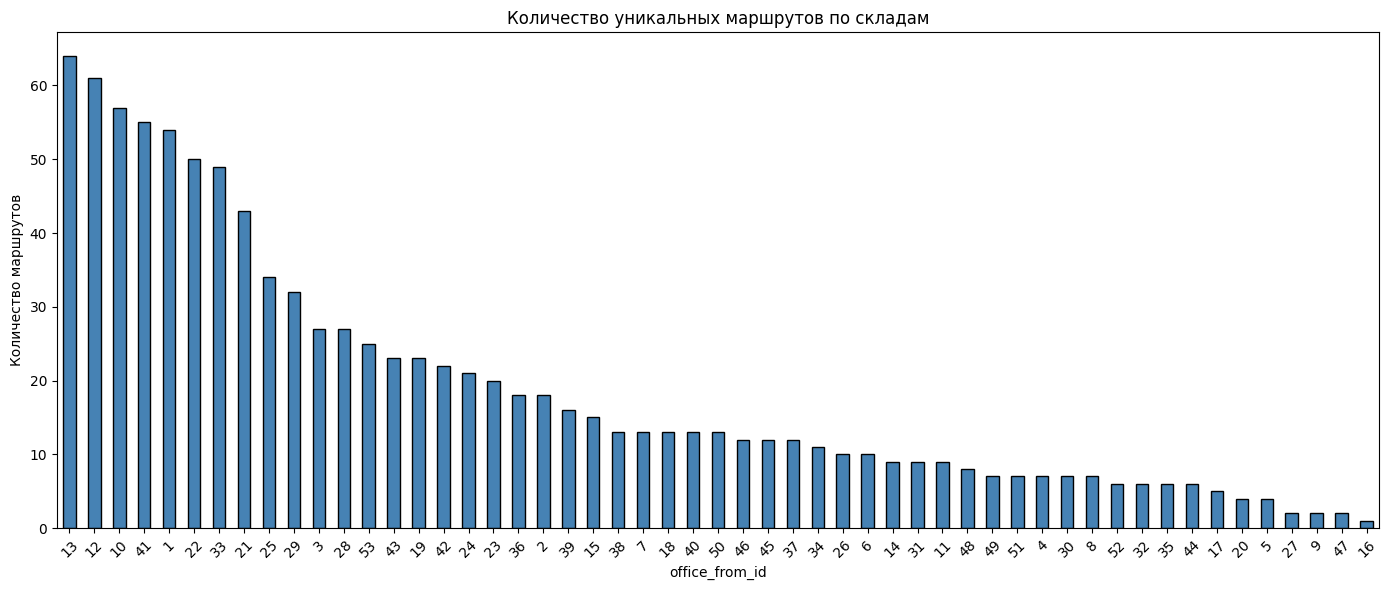

In [ ]:
# Сколько уникальных маршрутов на каждый склад
routes_per_office = train.groupby('office_from_id')['route_id'].nunique().sort_values(ascending=False)

print("Количество уникальных маршрутов по складам:")
print(routes_per_office)

# График
plt.figure(figsize=(14, 6))
routes_per_office.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Количество уникальных маршрутов по складам')
plt.xlabel('office_from_id')
plt.ylabel('Количество маршрутов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# ВИЗУАЛИЗАЦИЯ: SANKEY DIAGRAM - ВСЕ СКЛАДЫ И МАРШРУТЫ
# =============================================================================

import plotly.graph_objects as go

# Агрегируем данные по ВСЕМ складам и маршрутам
sankey_data = train.groupby(['office_from_id', 'route_id'])['target_2h'].sum().reset_index()
sankey_data.columns = ['source', 'target', 'value']

print(f"Всего складов: {sankey_data['source'].nunique()}")
print(f"Всего маршрутов: {sankey_data['target'].nunique()}")
print(f"Всего связей: {len(sankey_data)}")

# Создаём маппинг для индексов
all_offices = sankey_data['source'].unique()
all_routes = sankey_data['target'].unique()

# Склады (0 to N-1), Маршруты (N to N+M-1)
office_mapping = {office: i for i, office in enumerate(all_offices)}
route_mapping = {route: i + len(all_offices) for i, route in enumerate(all_routes)}

# Подготавливаем данные для Sankey
source = [office_mapping[s] for s in sankey_data['source']]
target = [route_mapping[t] for t in sankey_data['target']]
values = sankey_data['value'].tolist()

# Labels
labels = [f'Склад {o}' for o in all_offices] + [f'Маршрут {t}' for t in all_routes]

# Цвета - градиент для складов и маршрутов
node_colors = ['lightcoral'] * len(all_offices) + ['lightblue'] * len(all_routes)

# Создаём диаграмму
fig = go.Figure(data=[go.Sankey(
    node = dict(
        pad = 10,  # Уменьшили pad для компактности
        thickness = 10,  # Уменьшили thickness
        line = dict(color = "black", width = 0.3),
        label = labels,
        color = node_colors,
        x = [0.1] * len(all_offices) + [0.9] * len(all_routes),
    ),
    link = dict(
        source = source,
        target = target,
        value = values,
        color = [f'rgba(100, 150, 255, {min(v/max(values), 0.5)})' for v in values],  # Более прозрачные
        line = dict(color = "black", width = 0.5)
    )
)])

fig.update_layout(
    title_text="Потоки отгрузок: ВСЕ Склады → ВСЕ Маршруты",
    font_size=8,  # Уменьшили шрифт
    height=1000,  # Увеличили высоту
    width=1400    # Увеличили ширину
)

fig.show()

Всего складов: 53
Всего маршрутов: 1000
Всего связей: 1000


In [ ]:
# =============================================================================
# ВИЗУАЛИЗАЦИЯ: SANKEY DIAGRAM - ВСЕ данные с фильтром по объёму
# =============================================================================

import plotly.graph_objects as go
qt = 0.9

# Агрегируем данные
sankey_data = train.groupby(['office_from_id', 'route_id'])['target_2h'].sum().reset_index()
sankey_data.columns = ['source', 'target', 'value']

# Фильтруем связи по минимальному объёму (убираем очень мелкие потоки)
MIN_VOLUME = sankey_data['value'].quantile(qt)  # Оставляем топ-50% по объёму
sankey_filtered = sankey_data[sankey_data['value'] >= MIN_VOLUME]

print(f"Всего связей: {len(sankey_data)}")
print(f"После фильтрации: {len(sankey_filtered)}")
print(f"Минимальный объём для отображения: {MIN_VOLUME:.0f}")

# Создаём маппинг
all_offices = sankey_filtered['source'].unique()
all_routes = sankey_filtered['target'].unique()

office_mapping = {office: i for i, office in enumerate(all_offices)}
route_mapping = {route: i + len(all_offices) for i, route in enumerate(all_routes)}

# Подготавливаем данные
source = [office_mapping[s] for s in sankey_filtered['source']]
target = [route_mapping[t] for t in sankey_filtered['target']]
values = sankey_filtered['value'].tolist()

# Labels
labels = [f'Склад {o}' for o in all_offices] + [f'Маршрут {t}' for t in all_routes]

# Цвета - можно сделать градиент по объёму
node_colors = ['lightcoral'] * len(all_offices) + ['lightblue'] * len(all_routes)

# Создаём диаграмму
fig = go.Figure(data=[go.Sankey(
    node = dict(
        pad = 12,
        thickness = 15,
        line = dict(color = "black", width = 0.5),
        label = labels,
        color = node_colors,
        x = [0.1] * len(all_offices) + [0.9] * len(all_routes),
    ),
    link = dict(
        source = source,
        target = target,
        value = values,
        color = [f'rgba(100, 150, 255, {min(v/max(values), 0.7)})' for v in values],
    )
)])

fig.update_layout(
    title_text=f"Потоки отгрузок: Склады → Маршруты (топ-{int(100*(1-qt))}% связей по объёму)",
    font_size=9,
    height=900,
    width=1400
)

fig.show()

Всего связей: 1000
После фильтрации: 100
Минимальный объём для отображения: 630913


In [ ]:
# =============================================================================
# ПРОВЕРКА: Сколько складов может обслуживать один маршрут?
# =============================================================================

print("=" * 60)
print("ПРОВЕРКА СВЯЗИ МАРШРУТ ↔ СКЛАД")
print("=" * 60)

# Группируем по route_id и считаем уникальные office_from_id
route_to_office = train.groupby('route_id')['office_from_id'].nunique()

print(f"\n📊 Статистика:")
print(f"Всего маршрутов: {len(route_to_office)}")
print(f"Маршрутов с 1 складом: {(route_to_office == 1).sum()}")
print(f"Маршрутов с >1 складом: {(route_to_office > 1).sum()}")

# Если есть маршруты с несколькими складами - покажем примеры
if (route_to_office > 1).sum() > 0:
    print(f"\n⚠️  Примеры маршрутов с несколькими складами:")
    multi_office_routes = route_to_office[route_to_office > 1].head(10)
    for route_id, num_offices in multi_office_routes.items():
        offices = train[train['route_id'] == route_id]['office_from_id'].unique()
        print(f"  Маршрут {route_id}: {num_offices} склад(а) → {list(offices)}")
else:
    print(f"\n✅ Все маршруты привязаны только к одному складу!")

# Обратная проверка: сколько маршрутов у каждого склада
office_to_route = train.groupby('office_from_id')['route_id'].nunique()
print(f"\n📊 Статистика по складам:")
print(f"Всего складов: {len(office_to_route)}")
print(f"Минимум маршрутов у склада: {office_to_route.min()}")
print(f"Максимум маршрутов у склада: {office_to_route.max()}")
print(f"В среднем маршрутов на склад: {office_to_route.mean():.1f}")

# Топ-5 складов по количеству маршрутов
print(f"\n🏆 Топ-5 складов по количеству маршрутов:")
print(office_to_route.sort_values(ascending=False).head(5))

ПРОВЕРКА СВЯЗИ МАРШРУТ ↔ СКЛАД

📊 Статистика:
Всего маршрутов: 1000
Маршрутов с 1 складом: 1000
Маршрутов с >1 складом: 0

✅ Все маршруты привязаны только к одному складу!

📊 Статистика по складам:
Всего складов: 53
Минимум маршрутов у склада: 1
Максимум маршрутов у склада: 64
В среднем маршрутов на склад: 18.9

🏆 Топ-5 складов по количеству маршрутов:
office_from_id
13    64
12    61
10    57
41    55
1     54
Name: route_id, dtype: int64


АНАЛИЗ АКТИВНОСТИ СКЛАДОВ И МАРШРУТОВ

📦 АКТИВНОСТЬ СКЛАДОВ (office_from_id):
                total_volume  avg_volume  record_count
office_from_id                                        
12                38449786.0      145.17        264862
1                 27236672.0      116.16        234468
22                23652198.0      108.95        217100
10                19022011.0       76.86        247494
21                17792389.0       95.30        186706
13                15017814.0       54.04        277888
33                14001531.0       65.81        212758
53                11798996.0      108.70        108550
36                 7961493.0      101.87         78156
38                 7351692.0      130.24         56446

...
                total_volume  avg_volume  record_count
office_from_id                                        
46                 1305447.0       25.05         52104
4                  1178178.0       38.76         30394
7                  1056737.0       18

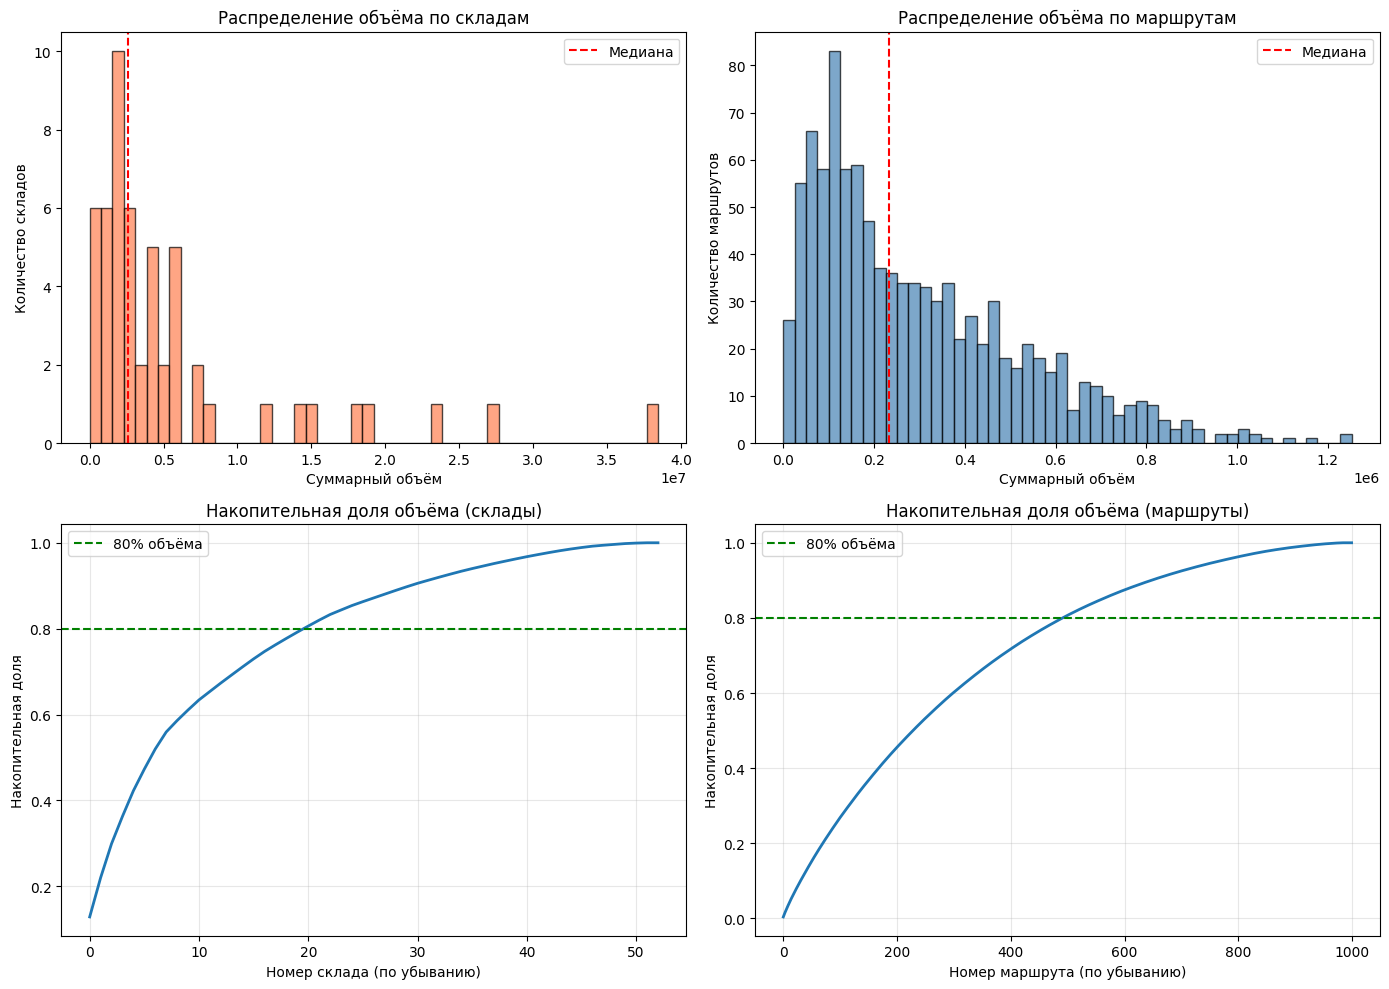


ПАРЕТО-АНАЛИЗ (Правило 80/20)

📦 21 складов (39.6%) дают 80% объёма
🚚 492 маршрутов (49.2%) дают 80% объёма


In [ ]:
# =============================================================================
# ПРОВЕРКА: Какие склады и маршруты НЕ используются?
# =============================================================================

print("=" * 60)
print("АНАЛИЗ АКТИВНОСТИ СКЛАДОВ И МАРШРУТОВ")
print("=" * 60)

# 1. Активность складов
print("\n📦 АКТИВНОСТЬ СКЛАДОВ (office_from_id):")
office_activity = train.groupby('office_from_id').agg({
    'target_2h': ['sum', 'mean', 'count']
}).round(2)
office_activity.columns = ['total_volume', 'avg_volume', 'record_count']
office_activity = office_activity.sort_values('total_volume', ascending=False)

print(office_activity.head(10))
print("\n...")
print(office_activity.tail(10))

# Склады с нулевым или минимальным объёмом
zero_office = office_activity[office_activity['total_volume'] == 0]
low_office = office_activity[office_activity['total_volume'] < office_activity['total_volume'].median()]

print(f"\n❌ Складов с нулевым объёмом: {len(zero_office)}")
print(f"📉 Складов ниже медианы: {len(low_office)} из {len(office_activity)}")

# 2. Активность маршрутов
print("\n🚚 АКТИВНОСТЬ МАРШРУТОВ (route_id):")
route_activity = train.groupby('route_id').agg({
    'target_2h': ['sum', 'mean', 'count']
}).round(2)
route_activity.columns = ['total_volume', 'avg_volume', 'record_count']
route_activity = route_activity.sort_values('total_volume', ascending=False)

print(route_activity.head(10))
print("\n...")
print(route_activity.tail(10))

# Маршруты с нулевым или минимальным объёмом
zero_route = route_activity[route_activity['total_volume'] == 0]
low_route = route_activity[route_activity['total_volume'] < route_activity['total_volume'].median()]

print(f"\n❌ Маршрутов с нулевым объёмом: {len(zero_route)}")
print(f"📉 Маршрутов ниже медианы: {len(low_route)} из {len(route_activity)}")

# 3. Визуализация распределения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Распределение объёма по складам
axes[0, 0].hist(office_activity['total_volume'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 0].set_title('Распределение объёма по складам')
axes[0, 0].set_xlabel('Суммарный объём')
axes[0, 0].set_ylabel('Количество складов')
axes[0, 0].axvline(office_activity['total_volume'].median(), color='red', linestyle='--', label='Медиана')
axes[0, 0].legend()

# Распределение объёма по маршрутам
axes[0, 1].hist(route_activity['total_volume'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].set_title('Распределение объёма по маршрутам')
axes[0, 1].set_xlabel('Суммарный объём')
axes[0, 1].set_ylabel('Количество маршрутов')
axes[0, 1].axvline(route_activity['total_volume'].median(), color='red', linestyle='--', label='Медиана')
axes[0, 1].legend()

# Cumulative распределение складов
office_sorted = office_activity['total_volume'].sort_values(ascending=False).reset_index(drop=True)
office_cumsum = office_sorted.cumsum() / office_sorted.sum()
axes[1, 0].plot(office_cumsum.index, office_cumsum.values, linewidth=2)
axes[1, 0].axhline(y=0.8, color='green', linestyle='--', label='80% объёма')
axes[1, 0].set_title('Накопительная доля объёма (склады)')
axes[1, 0].set_xlabel('Номер склада (по убыванию)')
axes[1, 0].set_ylabel('Накопительная доля')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Cumulative распределение маршрутов
route_sorted = route_activity['total_volume'].sort_values(ascending=False).reset_index(drop=True)
route_cumsum = route_sorted.cumsum() / route_sorted.sum()
axes[1, 1].plot(route_cumsum.index, route_cumsum.values, linewidth=2)
axes[1, 1].axhline(y=0.8, color='green', linestyle='--', label='80% объёма')
axes[1, 1].set_title('Накопительная доля объёма (маршруты)')
axes[1, 1].set_xlabel('Номер маршрута (по убыванию)')
axes[1, 1].set_ylabel('Накопительная доля')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Парето-анализ
print("\n" + "=" * 60)
print("ПАРЕТО-АНАЛИЗ (Правило 80/20)")
print("=" * 60)

# Сколько складов дают 80% объёма?
office_80_idx = (office_cumsum >= 0.8).idxmax()
print(f"\n📦 {office_80_idx + 1} складов ({(office_80_idx + 1) / len(office_activity) * 100:.1f}%) дают 80% объёма")

# Сколько маршрутов дают 80% объёма?
route_80_idx = (route_cumsum >= 0.8).idxmax()
print(f"🚚 {route_80_idx + 1} маршрутов ({(route_80_idx + 1) / len(route_activity) * 100:.1f}%) дают 80% объёма")

In [ ]:
route_volumes = train.groupby('route_id')['target_2h'].sum()
train['is_active_route'] = train['route_id'].map(
    lambda x: 1 if route_volumes[x] > 0 else 0
)

ОБЪЁМ НА ОДИН МАРШРУТ ПО СКЛАДАМ

Топ-5 складов по КОЛИЧЕСТВУ маршрутов:
                num_routes  total_volume  avg_volume_per_record  \
office_from_id                                                    
13                      64    15017814.0                  54.04   
12                      61    38449786.0                 145.17   
10                      57    19022011.0                  76.86   
41                      55     5659812.0                  23.70   
1                       54    27236672.0                 116.16   

                volume_per_route  
office_from_id                    
13                     234653.34  
12                     630324.36  
10                     333719.49  
41                     102905.67  
1                      504382.81  

Топ-5 складов по ОБЪЁМУ на 1 маршрут:
                num_routes  total_volume  avg_volume_per_record  \
office_from_id                                                    
12                      61    38449786.

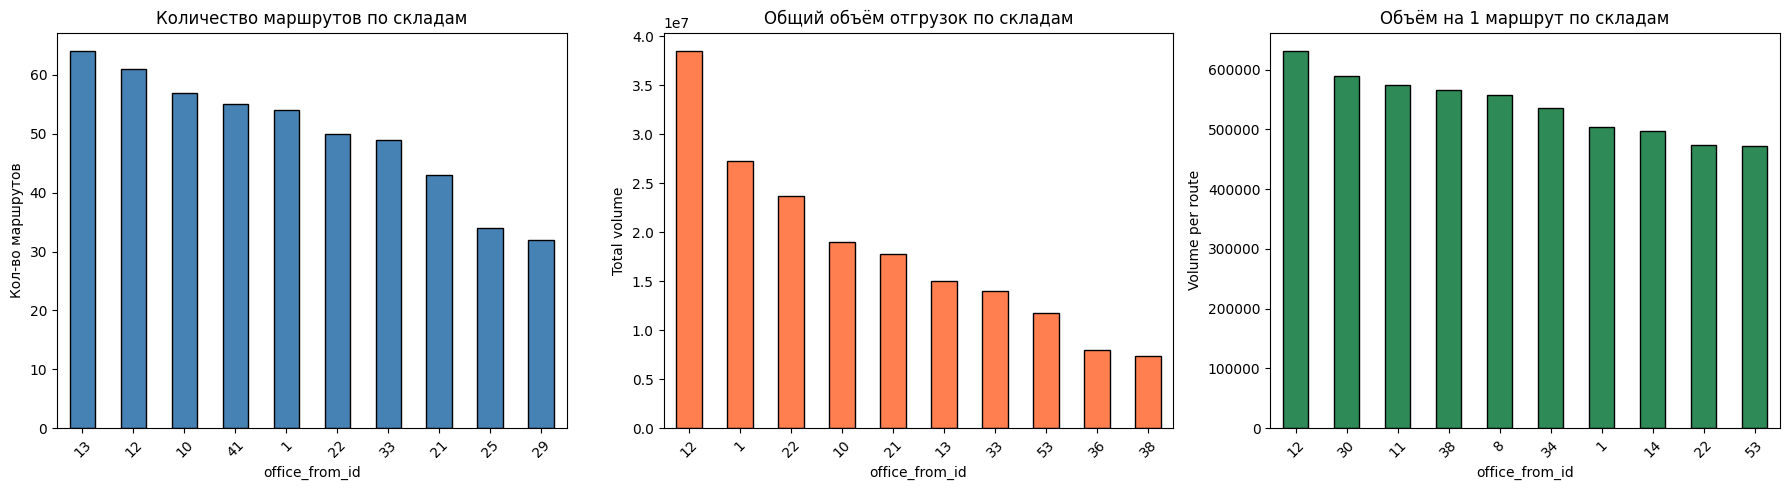


СРАВНЕНИЕ СКЛАДОВ 12 и 13
                num_routes  total_volume  avg_volume_per_record  \
office_from_id                                                    
12                      61    38449786.0                 145.17   
13                      64    15017814.0                  54.04   

                volume_per_route  
office_from_id                    
12                     630324.36  
13                     234653.34  


In [ ]:
# =============================================================================
# АНАЛИЗ: Объём на один маршрут по складам
# =============================================================================

print("=" * 60)
print("ОБЪЁМ НА ОДИН МАРШРУТ ПО СКЛАДАМ")
print("=" * 60)

# Считаем статистику по складам
office_stats = train.groupby('office_from_id').agg({
    'route_id': 'nunique',  # Количество уникальных маршрутов
    'target_2h': ['sum', 'mean']  # Общий объём и средний объём на запись
}).round(2)

office_stats.columns = ['num_routes', 'total_volume', 'avg_volume_per_record']

# Добавляем объём на 1 маршрут
office_stats['volume_per_route'] = (
    office_stats['total_volume'] / office_stats['num_routes']
).round(2)

# Сортируем по количеству маршрутов
print("\nТоп-5 складов по КОЛИЧЕСТВУ маршрутов:")
print(office_stats.sort_values('num_routes', ascending=False).head(5))

# Сортируем по объёму на маршрут
print("\nТоп-5 складов по ОБЪЁМУ на 1 маршрут:")
print(office_stats.sort_values('volume_per_route', ascending=False).head(5))

# Сортируем по общему объёму
print("\nТоп-5 складов по ОБЩЕМУ объёму:")
print(office_stats.sort_values('total_volume', ascending=False).head(5))

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Количество маршрутов
office_stats.sort_values('num_routes', ascending=False).head(10)['num_routes'].plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Количество маршрутов по складам')
axes[0].set_xlabel('office_from_id')
axes[0].set_ylabel('Кол-во маршрутов')
axes[0].tick_params(axis='x', rotation=45)

# 2. Общий объём
office_stats.sort_values('total_volume', ascending=False).head(10)['total_volume'].plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('Общий объём отгрузок по складам')
axes[1].set_xlabel('office_from_id')
axes[1].set_ylabel('Total volume')
axes[1].tick_params(axis='x', rotation=45)

# 3. Объём на 1 маршрут
office_stats.sort_values('volume_per_route', ascending=False).head(10)['volume_per_route'].plot(
    kind='bar', ax=axes[2], color='seagreen', edgecolor='black'
)
axes[2].set_title('Объём на 1 маршрут по складам')
axes[2].set_xlabel('office_from_id')
axes[2].set_ylabel('Volume per route')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Конкретно по складам 12 и 13
print("\n" + "=" * 60)
print("СРАВНЕНИЕ СКЛАДОВ 12 и 13")
print("=" * 60)
comparison = office_stats.loc[[12, 13]]
print(comparison)

In [ ]:
train['hour'] = train['timestamp'].dt.hour
train['day_of_week'] = train['timestamp'].dt.dayofweek
train['month'] = train['timestamp'].dt.month
train['day'] = train['timestamp'].dt.day
train['is_weekend'] = (train['day_of_week'] >= 5).astype(int)
train['is_peak_hour'] = train['hour'].isin([9, 10, 11, 14, 15, 16]).astype(int)
train['hour_sin'] = np.sin(2 * np.pi * train['hour'] / 24)
train['hour_cos'] = np.cos(2 * np.pi * train['hour'] / 24)

In [ ]:
# Статистика по складам
office_stats = train.groupby('office_from_id').agg({
    'target_2h': ['mean', 'std', 'sum', 'count'],
    'status_1': ['mean', 'sum'],
    'status_2': ['mean', 'sum'],
    # ... для всех status
}).reset_index()
office_stats.columns = ['office_from_id'] + [f'{col[0]}_{col[1]}' for col in office_stats.columns[1:]]

# Статистика по маршрутам
route_stats = train.groupby('route_id').agg({
    'target_2h': ['mean', 'std', 'sum', 'count']
}).reset_index()

In [ ]:
# Сортировка по времени
train = train.sort_values('timestamp')

# Rolling statistics по office
for col in ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6']:
    train[f'{col}_rolling_mean_3h'] = train.groupby('office_from_id')[col].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )
    train[f'{col}_rolling_std_3h'] = train.groupby('office_from_id')[col].transform(
        lambda x: x.rolling(window=3, min_periods=1).std()
    )

In [ ]:
# Target encoding для office и route
office_target = train.groupby('office_from_id')['target_2h'].mean()
route_target = train.groupby('route_id')['target_2h'].mean()

train['office_target_enc'] = train['office_from_id'].map(office_target)
train['route_target_enc'] = train['route_id'].map(route_target)

# Label Encoding для ID
from sklearn.preprocessing import LabelEncoder
le_office = LabelEncoder()
le_route = LabelEncoder()

train['office_encoded'] = le_office.fit_transform(train['office_from_id'])
train['route_encoded'] = le_route.fit_transform(train['route_id'])

In [ ]:
# Сумма и среднее по всем status
status_cols = ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']

train['status_sum'] = train[status_cols].sum(axis=1)
train['status_mean'] = train[status_cols].mean(axis=1)
train['status_max'] = train[status_cols].max(axis=1)
train['status_min'] = train[status_cols].min(axis=1)
train['status_std'] = train[status_cols].std(axis=1)
train['status_count_nonzero'] = (train[status_cols] > 0).sum(axis=1)

# Взаимодействия между status
train['status_1_2_ratio'] = train['status_1'] / (train['status_2'] + 1)
train['status_3_4_ratio'] = train['status_3'] / (train['status_4'] + 1)

In [ ]:
# Часовые паттерны по office
hourly_stats = train.groupby(['office_from_id', 'hour'])['target_2h'].agg(['mean', 'std', 'count']).reset_index()
hourly_stats.columns = ['office_from_id', 'hour', 'target_hour_mean', 'target_hour_std', 'target_hour_count']

train = train.merge(hourly_stats, on=['office_from_id', 'hour'], how='left')

# Дневные паттерны по office
daily_stats = train.groupby(['office_from_id', 'day_of_week'])['target_2h'].agg(['mean', 'std']).reset_index()
daily_stats.columns = ['office_from_id', 'day_of_week', 'target_day_mean', 'target_day_std']

train = train.merge(daily_stats, on=['office_from_id', 'day_of_week'], how='left')

In [ ]:
# Определение выбросов по target
Q1 = train['target_2h'].quantile(0.25)
Q3 = train['target_2h'].quantile(0.75)
IQR = Q3 - Q1

train['target_lower_bound'] = Q1 - 1.5 * IQR
train['target_upper_bound'] = Q3 + 1.5 * IQR
train['is_target_outlier'] = ((train['target_2h'] < train['target_lower_bound']) |
                               (train['target_2h'] > train['target_upper_bound'])).astype(int)

# Логарифмирование target (если есть выбросы)
train['target_2h_log'] = np.log1p(train['target_2h'])

In [ ]:
# Взаимодействие office и времени
train['office_hour'] = train['office_from_id'].astype(str) + '_' + train['hour'].astype(str)
train['office_day'] = train['office_from_id'].astype(str) + '_' + train['day_of_week'].astype(str)

# Взаимодействие status с временем
train['status_sum_hour'] = train['status_sum'] * train['hour']
train['status_sum_day'] = train['status_sum'] * train['day_of_week']

In [ ]:
train

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,...,target_day_std,target_lower_bound,target_upper_bound,is_target_outlier,target_2h_log,office_hour,office_day,status_sum_hour,status_sum_day,office_from_id_encoded
0,4,29,2025-03-01 00:00:00,3105,340,2160,484,4018,3462,0,...,68.042652,-102.5,221.5,0,3.332205,4_0,4_5,0,67845,3
1,7,867,2025-03-01 00:00:00,760,50,773,856,859,217,485,...,9.075874,-102.5,221.5,0,2.197225,7_0,7_5,0,20000,6
2,37,815,2025-03-01 00:00:00,31,61,96,352,250,290,0,...,19.132851,-102.5,221.5,0,0.000000,37_0,37_5,0,5400,36
3,41,799,2025-03-01 00:00:00,513,41,1177,746,637,1664,593,...,10.966849,-102.5,221.5,0,2.564949,41_0,41_5,0,26855,40
4,33,719,2025-03-01 00:00:00,41,585,33,336,783,1081,1308,...,42.495292,-102.5,221.5,0,4.204693,33_0,33_5,0,22355,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4341995,10,349,2025-05-30 10:30:00,1475,147,1059,1196,911,1318,0,...,65.647968,-102.5,221.5,0,3.332205,10_10,10_4,77870,31148,9
4341996,41,890,2025-05-30 10:30:00,2030,54,1493,1978,2645,2205,0,...,11.494598,-102.5,221.5,0,2.944439,41_10,41_4,104050,41620,40
4341997,28,849,2025-05-30 10:30:00,0,323,0,271,548,305,0,...,71.294143,-102.5,221.5,0,3.871201,28_10,28_4,20790,8316,27
4341998,20,556,2025-05-30 10:30:00,0,30,0,0,4,25,0,...,66.427586,-102.5,221.5,0,5.170484,20_10,20_4,590,236,19
